In [1]:
import lime
import matplotlib.pyplot as plt
from lime import lime_image
import numpy as np
from skimage.segmentation import mark_boundaries
import skimage
from skimage.segmentation import slic

from captum.attr import Saliency
from captum.attr import IntegratedGradients

import torch 
from torchvision import datasets, transforms
transform = transforms.ToTensor()
test_dataset = datasets.MNIST(root="../data", train=False, download=True, transform=transform)

In [2]:
# load the model by An et al. (2020)
from Models.modelM5 import ModelM5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ModelM5().to(device)
model.load_state_dict(torch.load("Models/model004.pth"))
model.eval()

C:\Users\merli\AppData\Local\Temp\ipykernel_25392\260027207.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("Models/model004.pth"))


ModelM5(
  (conv1): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), bias=False)
  (conv1_bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), bias=False)
  (conv2_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 96, kernel_size=(5, 5), stride=(1, 1), bias=False)
  (conv3_bn): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(96, 128, kernel_size=(5, 5), stride=(1, 1), bias=False)
  (conv4_bn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv5): Conv2d(128, 160, kernel_size=(5, 5), stride=(1, 1), bias=False)
  (conv5_bn): BatchNorm2d(160, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=10240, out_features=10, bias=False)
  (fc1_bn): BatchNorm1d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tr

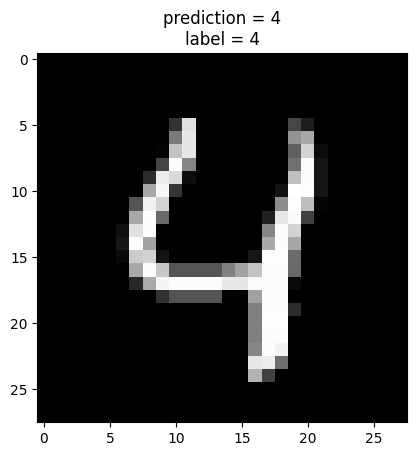

In [3]:
# load an image form the MNIST dataset
image, label = test_dataset[4]

plt.imshow(image.squeeze(0), cmap="gray")

# add another dimension 
image = image.unsqueeze(0).to(device)

# predict the label
output = model(image)
pred = output.argmax(dim=1)

plt.title(f"prediction = {pred.item()}\nlabel = {label}")
plt.show()

### LIME

In [4]:
# LIME
explainer = lime_image.LimeImageExplainer()

In [5]:
# convert image to rgb and numpy
image_numpy = image.squeeze(0).cpu().numpy()
image_rgb = np.repeat(image_numpy.squeeze(0)[:, :, np.newaxis], 3, axis=2)

In [6]:
def model_for_lime(images):
    """
    A wrapper for the CNN, this was LIME can use it
    :param images: 
    :return: 
    """
    # convert back to 1 channel
    batch = torch.tensor(np.mean(images, axis=3, keepdims=True)).permute(0, 3, 1, 2).float()
    batch = batch.to(device)
    
    with torch.no_grad():
        probs = torch.softmax(model(batch), dim=1)
    return probs.cpu().numpy()

def smaller_segments(image):
    """
    Allows LIME to have more segments on a small image
    :param image: 
    :return: 
    """
    return slic(image, n_segments = 20)

In [7]:
# create explanation
explanation = explainer.explain_instance(image_rgb, model_for_lime, top_labels= 1,  num_samples=1000, segmentation_fn=smaller_segments)

  0%|          | 0/1000 [00:00<?, ?it/s]

C:\Users\merli\AppData\Local\Temp\ipykernel_25392\3936564927.py:2: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skimage.io.imshow(skimage.segmentation.mark_boundaries(image_rgb, explanation.segments, mode="subpixel"))
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.1660291..1.1767669].


Nb of superpixels:  21


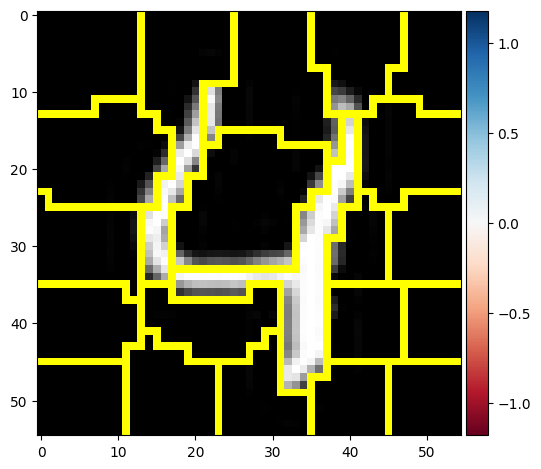

In [8]:
# All superpixels
skimage.io.imshow(skimage.segmentation.mark_boundaries(image_rgb, explanation.segments, mode="subpixel"))
print("Nb of superpixels: ",len(np.unique(explanation.segments)))

### Vanilla gradients and Intergraded Gradients

In [13]:
saliency = Saliency(model)

#compute saliency map
sal_map = saliency.attribute(image, target=pred.item()).squeeze().cpu().detach().numpy()

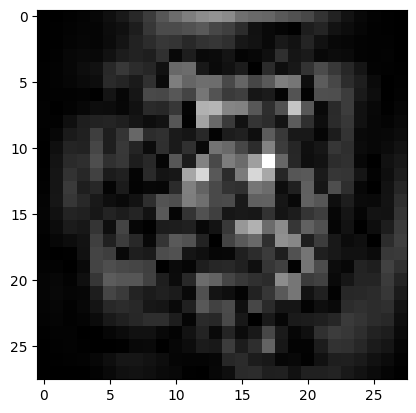

In [14]:
plt.imshow(sal_map, cmap= "gray")
plt.show()

In [15]:
ig = IntegratedGradients(model)
image_attr, delta = ig.attribute(image, n_steps=100, target=label, return_convergence_delta=True)

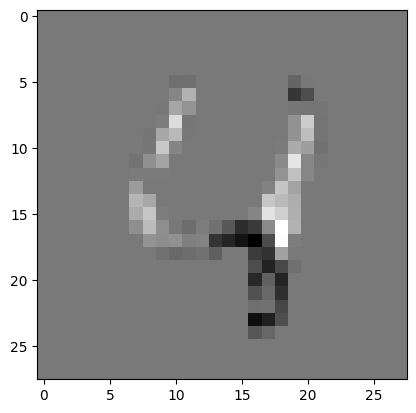

In [16]:
plt.imshow(image_attr.squeeze().cpu().detach().numpy(), cmap= "gray")
plt.show()

### With noise addition